# Skilling Experiment 5
## Diabetes Severity --- Multinomial Logistic Regression

**25SC2107E -- Machine Learning** | Course Outcome: CO2 | Dataset: Pima Indians Diabetes

---

### Aim
Clean a dataset where **missing values were recorded as zeros**, turn a continuous glucose
reading into three severity classes, and fit a **multinomial** logistic regression to
predict them.

The central lesson: **a single accuracy number can hide a model that has completely given
up on two of its three classes.**

### Before you start
Run each cell with `Shift+Enter`, in order. `diabetes.csv` must sit in the same folder as
this notebook. Everything uses `random_state=42`, so your numbers should match the manual.

## Cell 1 --- Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix

`SimpleImputer` is new. Experiments House Pricing and Breast Cancer used datasets with nothing missing, so this is
the first time you need it.

`f1_score` is the important import. **Accuracy alone will mislead you in this experiment**,
and F1 is what exposes the problem.

## Cell 2 --- Load the data

In [2]:
diabetes = pd.read_csv("diabetes.csv")

print(diabetes.shape)
print(diabetes.isna().sum().sum(), "values look missing")
diabetes.head()

(768, 9)
0 values look missing


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


768 rows and 9 columns.

**Pandas reports zero missing values. Do not believe it.** Nothing is marked `NaN`, so
every check you know how to run will say the data is clean. The next cell shows that it
is not.

## Cell 3 --- The zeros that are really missing values

In [3]:
suspect = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in suspect:
    n = (diabetes[col] == 0).sum()
    print("%-15s %3d zeros  (%.1f%%)" % (col, n, 100 * n / len(diabetes)))

diabetes[suspect] = diabetes[suspect].replace(0, np.nan)
print()
print(diabetes.isna().sum())

Glucose           5 zeros  (0.7%)
BloodPressure    35 zeros  (4.6%)
SkinThickness   227 zeros  (29.6%)
Insulin         374 zeros  (48.7%)
BMI              11 zeros  (1.4%)

Pregnancies           0
Glucose               5
BloodPressure        35
SkinThickness       227
Insulin             374
BMI                  11
DiabetesPedigree      0
Age                   0
Outcome               0
dtype: int64


Ask of each column: *is zero a possible reading for a living patient?* A BMI of 0, a blood
pressure of 0 and a glucose of 0 are all impossible. So those zeros mean "not recorded".

`Pregnancies` is deliberately **not** in the list. Zero pregnancies is a perfectly real
value. **You cannot apply this fix column by column without thinking** --- that is the
whole skill here.

The true picture is bad: **Insulin is 48.7% missing** and `SkinThickness` is 29.6% missing.

Had you skipped this step, the model would have treated hundreds of patients as having an
insulin level of zero, and every coefficient you read afterwards would have been meaningless.

## Cell 4 --- Build the severity target

Glucose range: 44.0 to 199.0
Severity
Low     192
Mid     374
High    197
Name: count, dtype: int64


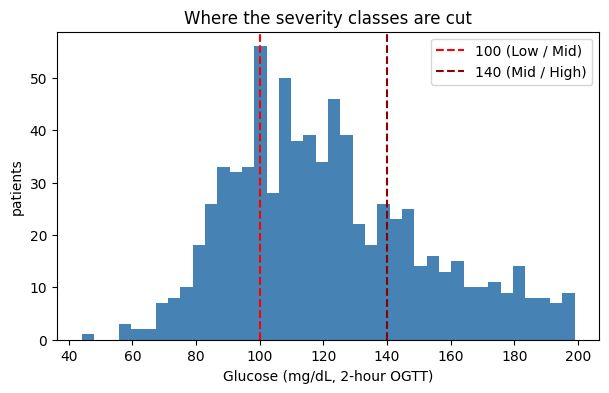

In [4]:
diabetes = diabetes.dropna(subset=["Glucose"]).reset_index(drop=True)

print("Glucose range:", diabetes["Glucose"].min(), "to", diabetes["Glucose"].max())

diabetes["Severity"] = pd.cut(diabetes["Glucose"],
                              bins=[0, 99.9, 139.9, 1000],
                              labels=["Low", "Mid", "High"])

print(diabetes["Severity"].value_counts().sort_index())

plt.figure(figsize=(7, 4))
plt.hist(diabetes["Glucose"], bins=40, color="steelblue")
plt.axvline(100, color="red", linestyle="--", label="100 (Low / Mid)")
plt.axvline(140, color="darkred", linestyle="--", label="140 (Mid / High)")
plt.xlabel("Glucose (mg/dL, 2-hour OGTT)")
plt.ylabel("patients")
plt.title("Where the severity classes are cut")
plt.legend()
plt.show()

The 5 patients whose `Glucose` is missing are **dropped, not imputed**. You may guess a
missing feature, but **you must never invent the answer you are trying to predict.** That
leaves 763 patients.

**The cut points are clinical, not arbitrary.** For a 2-hour OGTT, under 100 mg/dL is
normal, and 140 and above is the recognised threshold for impaired glucose tolerance.

**Look at the maximum: 199.** The true clinical marker for diabetes is 200, and not one
patient exceeds 199. The values were capped --- exactly like the \$500,000 cap in
House Pricing Prediction. Had we used 200 as a cut point, the High class would have been **empty**.

Classes come out at **192 Low, 374 Mid, 197 High**. Mid is about twice either of the
others. That mild imbalance is precisely what makes accuracy untrustworthy later.

## Cell 5 --- Remove the leak, then split 70/15/15

In [5]:
X = diabetes.drop(columns=["Glucose", "Severity"])
y = diabetes["Severity"].astype(str)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(X_train.shape, X_val.shape, X_test.shape)
print(X.columns.tolist())

(534, 8) (114, 8) (115, 8)
['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']


**Dropping `Glucose` is the most important line in this notebook.** `Severity` was cut
directly from `Glucose`, so leaving it in would let the model read the answer off its own
input. You would score close to 100% and have learned nothing. That mistake is called
**target leakage**.

What remains is a genuinely useful question: *can the other measurements tell us roughly
where a patient's glucose sits, without running the glucose test?*

**Three splits, not two**: 534 train, 114 validation, 115 test. You tune `C` on the
validation set and touch the test set **once**, at the very end.

## Cell 6 --- Impute, then scale

In [6]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_s = scaler.fit_transform(imputer.fit_transform(X_train))
X_val_s = scaler.transform(imputer.transform(X_val))
X_test_s = scaler.transform(imputer.transform(X_test))

print(pd.Series(imputer.statistics_, index=X.columns).round(1).to_string())

Pregnancies           3.0
BloodPressure        72.0
SkinThickness        29.0
Insulin             122.0
BMI                  32.4
DiabetesPedigree      0.4
Age                  29.0
Outcome               0.0


**Median, not mean.** Insulin is strongly right-skewed, and a handful of very high readings
would drag the mean upwards. The median is unmoved by them.

**`fit_transform` on train, `transform` on validation and test.** The median is computed
from the training patients alone. Computing it over the whole dataset would let information
from the test set seep into training --- a second, subtler kind of leakage.

Imputing first and scaling second is the right order: `StandardScaler` cannot handle `NaN`.

Be honest about what this costs: nearly half the insulin values are now a single repeated
number, which weakens that column. **Reporting that limitation is part of the result.**

## Cell 7 --- Baseline, then the first multinomial fit

In [7]:
print("always-Mid baseline:", round((y_val == "Mid").mean(), 4))

model = LogisticRegression(C=1, max_iter=5000, random_state=42)
model.fit(X_train_s, y_train)

pred = model.predict(X_val_s)
print("validation accuracy:", round(accuracy_score(y_val, pred), 4))
print("classes_:", model.classes_)
print("coef_ shape:", model.coef_.shape)

always-Mid baseline: 0.4912
validation accuracy: 0.6316
classes_: ['High' 'Low' 'Mid']
coef_ shape: (3, 8)


The baseline is **0.4912**: always answering "Mid" is right about half the time. The model
reaches **0.6316**, so it has genuinely learned something --- but a 63% classifier is not a
clinical instrument, and the honest framing is that these features carry only a moderate
signal about glucose.

**`coef_` has shape (3, 8): three rows of eight weights.** Binary logistic regression gives
one row. Multinomial gives **one row per class**.

**Read `classes_` carefully. It prints `['High' 'Low' 'Mid']`** --- alphabetical order, not
the Low/Mid/High order you defined. **Row 0 of `coef_` is High, not Low.** Assuming your own
order here is one of the easiest ways to publish a completely wrong interpretation.

---
## `multi_class="multinomial"` no longer exists

Older tutorials, and most answers you will find online, write this:

```python
model = LogisticRegression(multi_class="multinomial")   # fails
```

In current scikit-learn that raises:

```
TypeError: __init__() got an unexpected keyword argument 'multi_class'
```

The argument was deprecated and has now been **removed**.

**You do not need it.** When `y` has more than two classes, `LogisticRegression` fits a
multinomial model automatically. Just leave the argument out. If you copy code from a
tutorial and hit this error, **delete the argument** rather than downgrading scikit-learn.

---

## Cell 8 --- Per-class F1 against C, and what accuracy was hiding

In [8]:
class_names = ["Low", "Mid", "High"]
rows = []

for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    m = LogisticRegression(C=C, max_iter=5000, random_state=42)
    m.fit(X_train_s, y_train)
    p = m.predict(X_val_s)
    f1s = f1_score(y_val, p, average=None, labels=class_names, zero_division=0)
    rows.append({"C": C, "overall_acc": accuracy_score(y_val, p),
                 "F1_Low": f1s[0], "F1_Mid": f1s[1], "F1_High": f1s[2]})

sweep = pd.DataFrame(rows).round(4)
sweep

,C,overall_acc,F1_Low,F1_Mid,F1_High
0,0.001,0.4912,0.0000,0.6588,0.0000
1,0.010,0.5351,0.1250,0.6443,0.4681
2,0.100,0.6228,0.6250,0.6560,0.5455
3,1.000,0.6316,0.5957,0.6613,0.5965
4,10.000,0.6316,0.5957,0.6613,0.5965
5,100.000,0.6316,0.5957,0.6613,0.5965


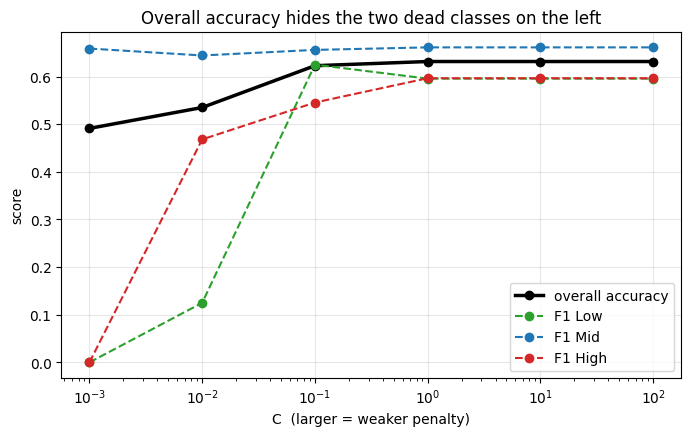

In [9]:
plt.figure(figsize=(8, 4.5))
plt.plot(sweep["C"], sweep["overall_acc"], marker="o", linewidth=2.5,
         color="black", label="overall accuracy")
for cls, colour in zip(class_names, ["tab:green", "tab:blue", "tab:red"]):
    plt.plot(sweep["C"], sweep["F1_" + cls], marker="o", linestyle="--",
             color=colour, label="F1 " + cls)
plt.xscale("log")
plt.xlabel("C  (larger = weaker penalty)")
plt.ylabel("score")
plt.title("Overall accuracy hides the two dead classes on the left")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Look at the first row, `C = 0.001`.** Overall accuracy is 0.4912, which sounds like a
weak-but-working model. It is not. **`F1_Low` and `F1_High` are both exactly 0.0000.**

That model answers "Mid" for **every single patient**. It never once says Low or High. It
scores 49% only because Mid really is 49% of the data --- it has exactly matched the
baseline while appearing to be a trained model.

**This is the point of the whole experiment. One accuracy number cannot tell the difference
between a model that has learned three classes and a model that has abandoned two of them.**
The per-class columns can, instantly.

Follow the columns downwards as the penalty weakens. `F1_High` climbs 0.0000, 0.4681,
0.5455, 0.5965 then stops. **The minority classes are the last to come back and the first
to be sacrificed** --- when a penalty forces the model to economise, it economises on the
small classes first.

`labels=class_names` is essential. Without it `f1_score` returns scores in **alphabetical**
order and your three columns would be silently mislabelled.

## Cell 9 --- One coefficient subplot per class

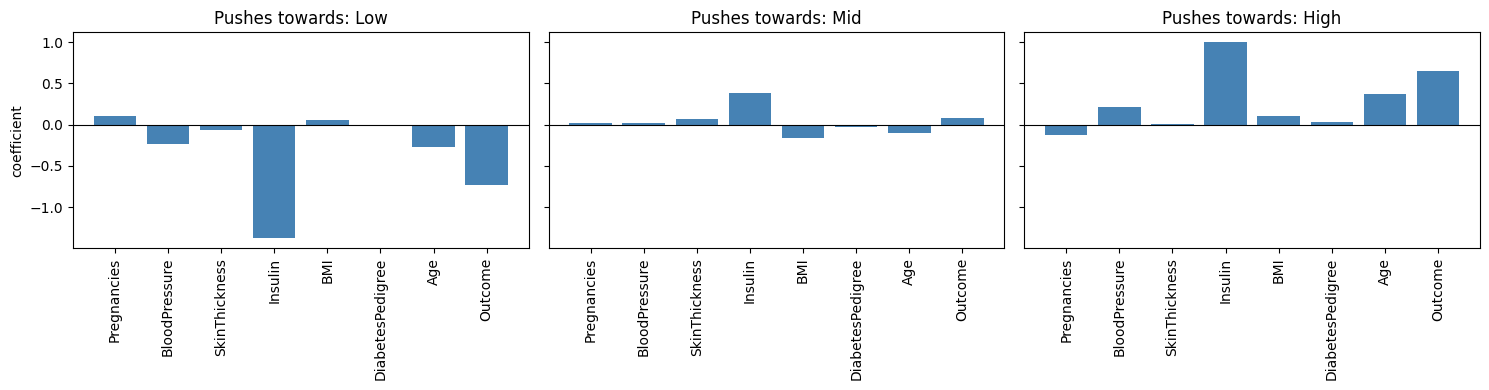

,Pregnancies,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
High,-0.131,0.208,0.006,1.000,0.108,0.033,0.367,0.653
Low,0.106,-0.230,-0.071,-1.378,0.053,-0.007,-0.271,-0.737
Mid,0.025,0.022,0.066,0.378,-0.160,-0.026,-0.096,0.084


In [10]:
best = LogisticRegression(C=1, max_iter=5000, random_state=42)
best.fit(X_train_s, y_train)

order = list(best.classes_)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, cls in zip(axes, class_names):
    row = best.coef_[order.index(cls)]
    ax.bar(X.columns, row, color="steelblue")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Pushes towards: " + cls)
    ax.tick_params(axis="x", rotation=90)

axes[0].set_ylabel("coefficient")
plt.tight_layout()
plt.show()

pd.DataFrame(best.coef_, index=best.classes_, columns=X.columns).round(3)

`order.index(cls)` looks the row up **by name** instead of trusting the position. Given that
`classes_` is alphabetical, hard-coding `coef_[0]` for Low would plot the **High** weights
under a Low heading.

**`Insulin` dominates every panel**, and its sign flips across them: about **-1.38 for Low**
and **+1.00 for High**. High insulin pushes hard towards the High class and hard away from
Low --- exactly the physiology you would expect, since insulin rises with glucose.

`Outcome` (the diabetes diagnosis) is the second strongest, again with opposite signs.

**The three rows compete, they are not independent.** Multinomial logistic regression scores
all three classes and takes the largest, so what matters is each feature's weight in one
panel *relative* to the others. This is why the Mid panel looks flat: **Mid wins by default**
when neither Low nor High makes a strong case.

## Cell 10 --- Pick C on validation, report once on test

In [11]:
final = LogisticRegression(C=1, max_iter=5000, random_state=42)
final.fit(X_train_s, y_train)
test_pred = final.predict(X_test_s)

print("baseline (always Mid):", round((y_test == "Mid").mean(), 4))
print("TEST accuracy       :", round(accuracy_score(y_test, test_pred), 4))
print()
print(classification_report(y_test, test_pred, labels=class_names,
                            zero_division=0))
print("confusion matrix (rows = truth), order Low / Mid / High:")
print(confusion_matrix(y_test, test_pred, labels=class_names))

baseline (always Mid): 0.487
TEST accuracy       : 0.6

              precision    recall  f1-score   support

         Low       0.57      0.45      0.50        29
         Mid       0.59      0.71      0.65        56
        High       0.67      0.53      0.59        30

    accuracy                           0.60       115
   macro avg       0.61      0.57      0.58       115
weighted avg       0.60      0.60      0.59       115

confusion matrix (rows = truth), order Low / Mid / High:
[[13 14  2]
 [10 40  6]
 [ 0 14 16]]


`C = 1` was the best validation score in Cell 8, so it is the one value carried through.

**Test accuracy is 0.6000, against 0.6316 on validation.** The drop is normal and worth
stating plainly: you chose `C` by looking at the validation set, so that score is mildly
optimistic. **The test number is the one you report.**

Against a 0.4870 baseline, 0.6000 is a real gain of about 11 points --- modest, honest, and
roughly what these features can support without the glucose reading itself.

In the confusion matrix, look at the Low--High corners. Confusing Low with Mid is a small
error; confusing **Low with High** means missing a patient at genuine clinical risk.
**Ordered classes make some mistakes worse than others**, and a plain accuracy score treats
them all alike.

---
## Deliverable --- `multinomial_analysis()`

Required signature and columns, straight from the handout:

`multinomial_analysis(X_train, y_train, X_val, y_val, class_names, C_values)`
returns a DataFrame with `[C, overall_acc, F1_Low, F1_Mid, F1_High]`.

In [12]:
def multinomial_analysis(X_train, y_train, X_val, y_val,
                         class_names, C_values):
    rows = []

    for C in C_values:
        model = LogisticRegression(C=C, max_iter=5000, random_state=42)
        model.fit(X_train, y_train)
        pred = model.predict(X_val)

        f1s = f1_score(y_val, pred, average=None, labels=class_names,
                       zero_division=0)

        row = {"C": C, "overall_acc": accuracy_score(y_val, pred)}
        for name, score in zip(class_names, f1s):
            row["F1_" + name] = score
        rows.append(row)

    return pd.DataFrame(rows).round(4)


results = multinomial_analysis(X_train_s, y_train, X_val_s, y_val,
                               ["Low", "Mid", "High"],
                               [0.001, 0.01, 0.1, 1, 10, 100])
results

,C,overall_acc,F1_Low,F1_Mid,F1_High
0,0.001,0.4912,0.0000,0.6588,0.0000
1,0.010,0.5351,0.1250,0.6443,0.4681
2,0.100,0.6228,0.6250,0.6560,0.5455
3,1.000,0.6316,0.5957,0.6613,0.5965
4,10.000,0.6316,0.5957,0.6613,0.5965
5,100.000,0.6316,0.5957,0.6613,0.5965


The required columns are `[C, overall_acc, F1_Low, F1_Mid, F1_High]`. Building them with
`"F1_" + name` in a loop means the function still works for four or five classes without a
rewrite --- **do not hard-code the three names**.

`class_names` is passed in and handed straight to `labels=`, so the caller's order is the
column order. **This is what keeps the labels honest.**

**How to read the finished table:** scan `overall_acc` for the best row, then check that
row's three F1 columns are all non-zero. **A high accuracy sitting beside a 0.0000 is not a
good model, it is a warning.**

The bottom three rows are identical. Beyond `C = 1` the penalty is so weak it no longer
binds. With 534 rows and only 8 features there is little to overfit --- the same situation
as House Pricing, and the opposite of Breast Cancer.

---
## What to take away

- **Zeros are not always zeros.** Check whether each value is physically possible before you
  trust a "no missing values" report. Judge it column by column: zero pregnancies is real,
  zero BMI is not.
- **Never leave the source column in.** If the target was built from `Glucose`, `Glucose`
  must go. A suspiciously excellent score is usually leakage, not skill.
- **Overall accuracy cannot see a dropped class.** A model predicting only the majority class
  scored 0.4912 here and looked plausible. Per-class F1 exposed it in one glance. **Whenever
  your classes are uneven, report per-class scores.**
- **Check `classes_` before reading any coefficient.** It is alphabetical, so it will rarely
  match the order you have in your head.

One limitation worth stating in your viva: Low, Mid and High are **ordered**, but multinomial
logistic regression does not know that. It treats them as three unrelated names, so predicting
High for a Low patient costs it exactly as much as predicting Mid. **Ordinal regression** is
the tool that uses the ordering, and it is the natural next step from here.

---
## Exercises

1. Put `Glucose` back into `X` and re-run Cell 7. What accuracy do you get, and why is it
   worthless? This is target leakage --- make sure you can recognise it.
2. Replace the clinical cut points with `pd.qcut(diabetes["Glucose"], 3)`. The classes become
   equal in size. Does `F1_Low` still collapse at `C = 0.001`? Explain the link to imbalance.
3. Use `strategy="mean"` instead of `"median"` in Cell 6. Which imputed value moves most,
   and why is Insulin the one to check?
4. Add `class_weight="balanced"` to the model in Cell 8. What happens to `F1_Low` and
   `F1_High` at small `C`, and what does overall accuracy do in exchange?
5. Drop `Outcome` from the features and re-run. How much accuracy came from that one column?
   Is it fair to use a diabetes diagnosis to predict a glucose category?